In [1]:
#Import Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import scipy.stats


In [61]:
#Read the data

In [62]:
df=pd.read_csv("Netflix Userbase.csv")

In [63]:
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [64]:
#Checking if any duplicates with user id
df.duplicated(subset='User ID').sum()

0

In [65]:
#Dropping unwanted columns
df.drop(['Plan Duration','User ID'],axis=1,inplace=True)

In [66]:
df.shape

(2500, 8)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Subscription Type  2500 non-null   object
 1   Monthly Revenue    2500 non-null   int64 
 2   Join Date          2500 non-null   object
 3   Last Payment Date  2500 non-null   object
 4   Country            2500 non-null   object
 5   Age                2500 non-null   int64 
 6   Gender             2500 non-null   object
 7   Device             2500 non-null   object
dtypes: int64(2), object(6)
memory usage: 156.4+ KB


In [68]:
df.describe()

,Monthly Revenue,Age
count,2500.000000,2500.000000
mean,12.508400,38.795600
std,1.686851,7.171778
min,10.000000,26.000000
25%,11.000000,32.000000
50%,12.000000,39.000000
75%,14.000000,45.000000
max,15.000000,51.000000


In [69]:
#check if the categorical variables have appropriate number of levels
df_category=df[['Subscription Type','Country','Gender','Device']]
df_category.nunique()

Subscription Type     3
Country              10
Gender                2
Device                4
dtype: int64

In [70]:
#check if the categorical variables have appropriate levels
for i in df_category.columns:
    print(i.upper(),":",df_category[i].unique())

SUBSCRIPTION TYPE : ['Basic' 'Premium' 'Standard']
COUNTRY : ['United States' 'Canada' 'United Kingdom' 'Australia' 'Germany' 'France'
 'Brazil' 'Mexico' 'Spain' 'Italy']
GENDER : ['Male' 'Female']
DEVICE : ['Smartphone' 'Tablet' 'Smart TV' 'Laptop']


In [71]:
#Univariate Analysis

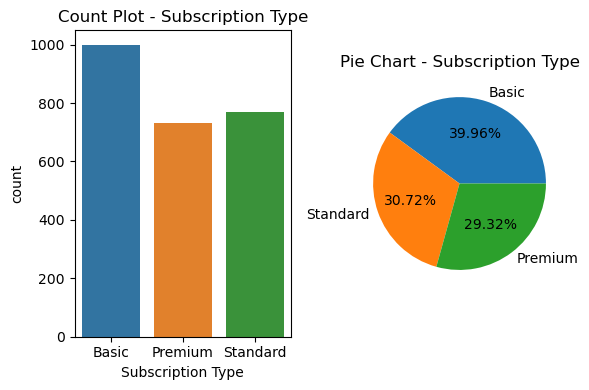

In [72]:
var='Subscription Type'

plt.figure(figsize = (6,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=var,data=df_category)
plt.title(f'Count Plot - {var}')

#piechart
plt.subplot(1,2,2)
counts=df_category[var].value_counts()
plt.pie(counts,labels=counts.index,autopct="%0.2f%%")
plt.title(f'Pie Chart - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

We see that there are subscriptions of Basic type to Netflix more than ofStandard and Premium types.
We can see that Standard and Premium types are nearly the same.
However, after all, the data is not that unbalanced when it comes to Subscription Type attribute.

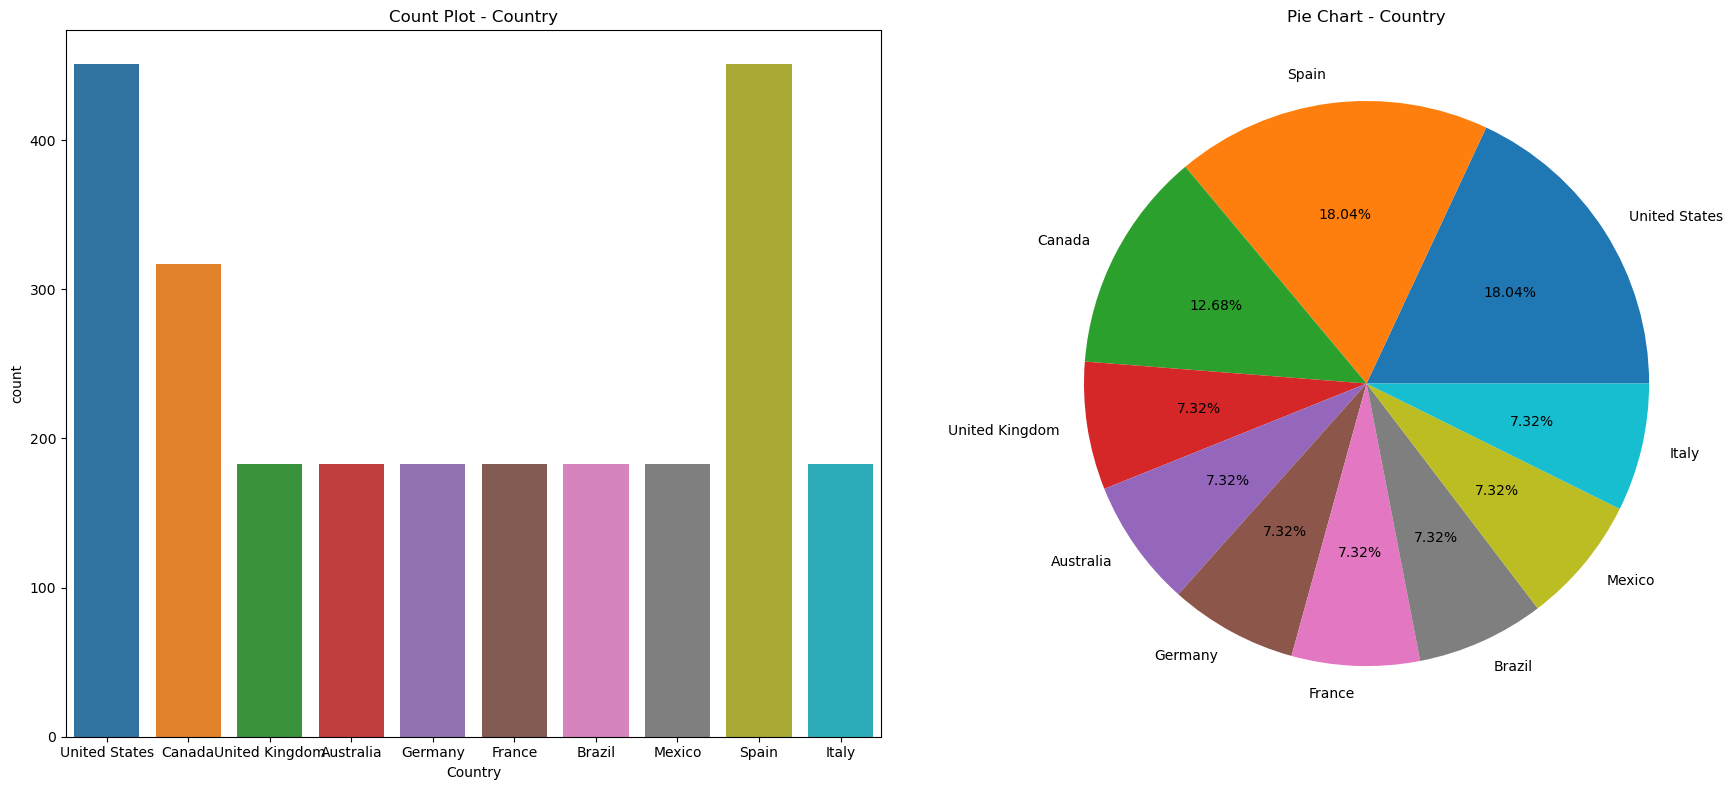

In [26]:
var='Country'

plt.figure(figsize = (18,8))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=var,data=df_category)
plt.title(f'Count Plot - {var}')

#piechart
plt.subplot(1,2,2)
counts=df_category[var].value_counts()
plt.pie(counts,labels=counts.index,autopct="%0.2f%%")
plt.title(f'Pie Chart - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

We notice that United States and Canada capture most of Netflix users origins with 18% for each, followed by United Kingdom with 12.7% of users' origins. Then come the rest of countries (Australia, Germany, France, Brazil, Mexico, Spain, Italy), all with the same percentage of 7.32%.



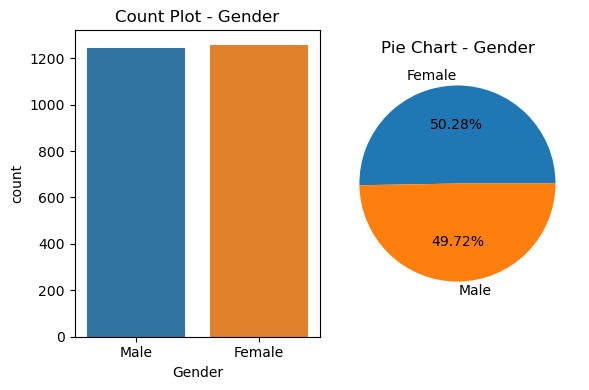

In [27]:
var='Gender'

plt.figure(figsize = (6,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=var,data=df_category)
plt.title(f'Count Plot - {var}')

#piechart
plt.subplot(1,2,2)
counts=df_category[var].value_counts()
plt.pie(counts,labels=counts.index,autopct="%0.2f%%")
plt.title(f'Pie Chart - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

The data collected based on Gender is satisfiably balanced, Netflix users are 50% men as it is for women.

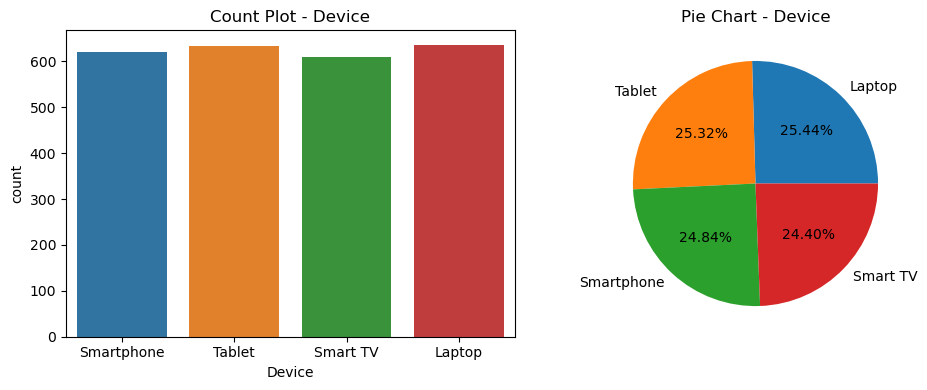

In [29]:
var='Device'

plt.figure(figsize = (10,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=var,data=df_category)
plt.title(f'Count Plot - {var}')

#piechart
plt.subplot(1,2,2)
counts=df_category[var].value_counts()
plt.pie(counts,labels=counts.index,autopct="%0.2f%%")
plt.title(f'Pie Chart - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

As the Gender column, Device column is so balanced, 25% of Netflix users watch Netlix using Smartphones. The same percentage of users goes to Tablet, Smart TV and Laptop.

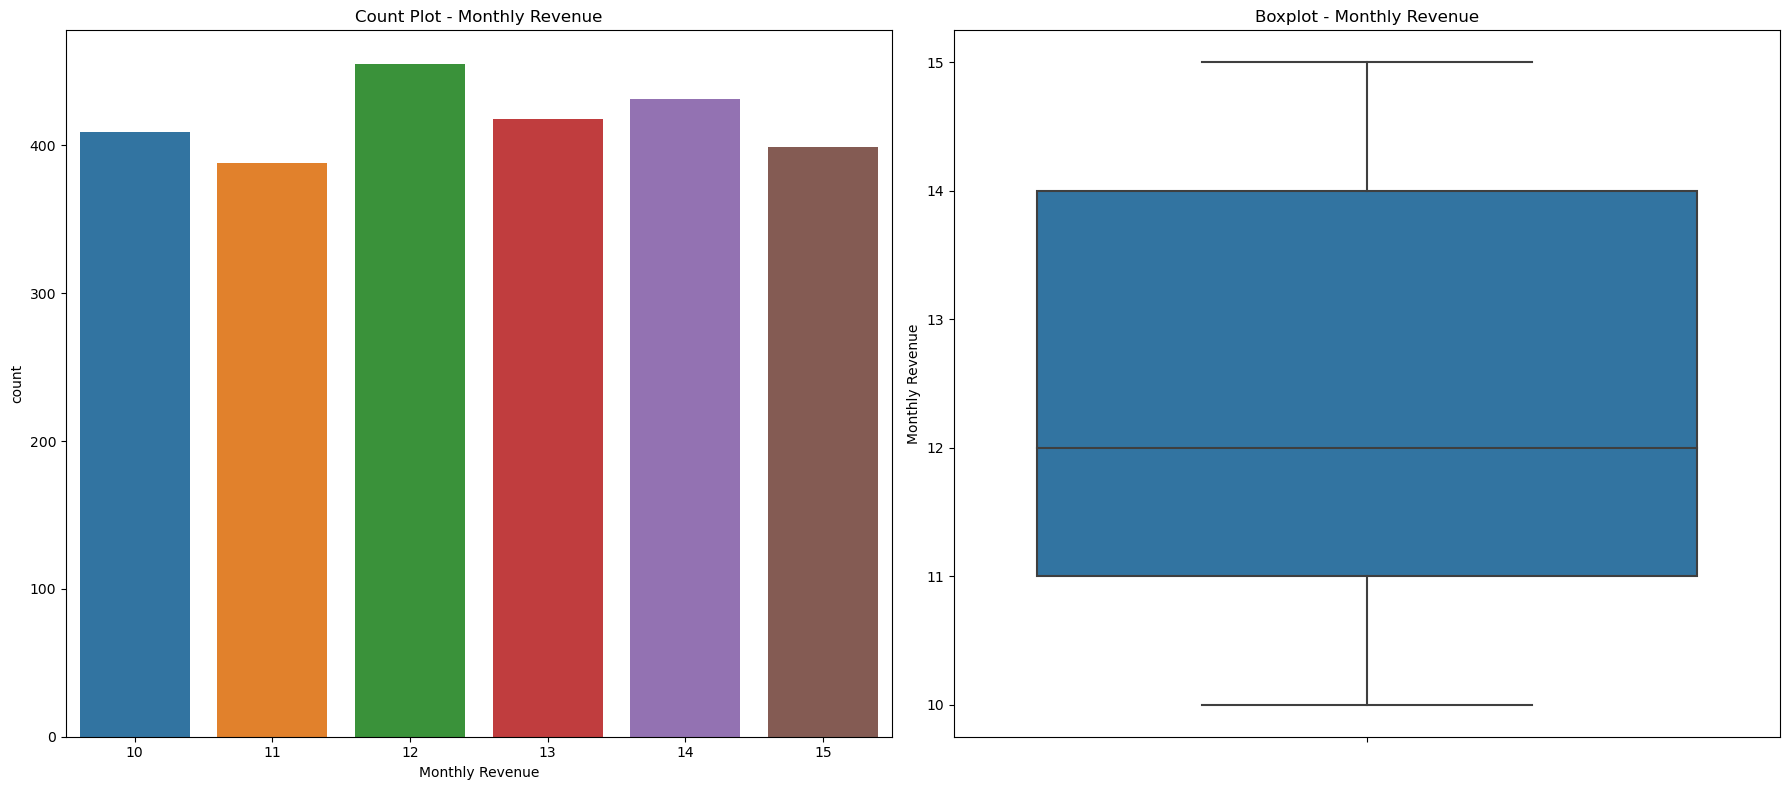

In [31]:
var='Monthly Revenue'

plt.figure(figsize = (18,8))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=var,data=df)
plt.title(f'Count Plot - {var}')

#piechart
plt.subplot(1,2,2)
sns.boxplot(y=var,data=df)
plt.title(f'Boxplot - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

We can see that Netflix users are nearly equally devided when it comes to the monthly revenues Netflix is profitting from them. However, more users are benifitting Netflix by 12 USD per moth more than other revenues.

In [32]:
#descriptive stats of Monthly Revenue
df['Monthly Revenue'].describe()

count    2500.000000
mean       12.508400
std         1.686851
min        10.000000
25%        11.000000
50%        12.000000
75%        14.000000
max        15.000000
Name: Monthly Revenue, dtype: float64

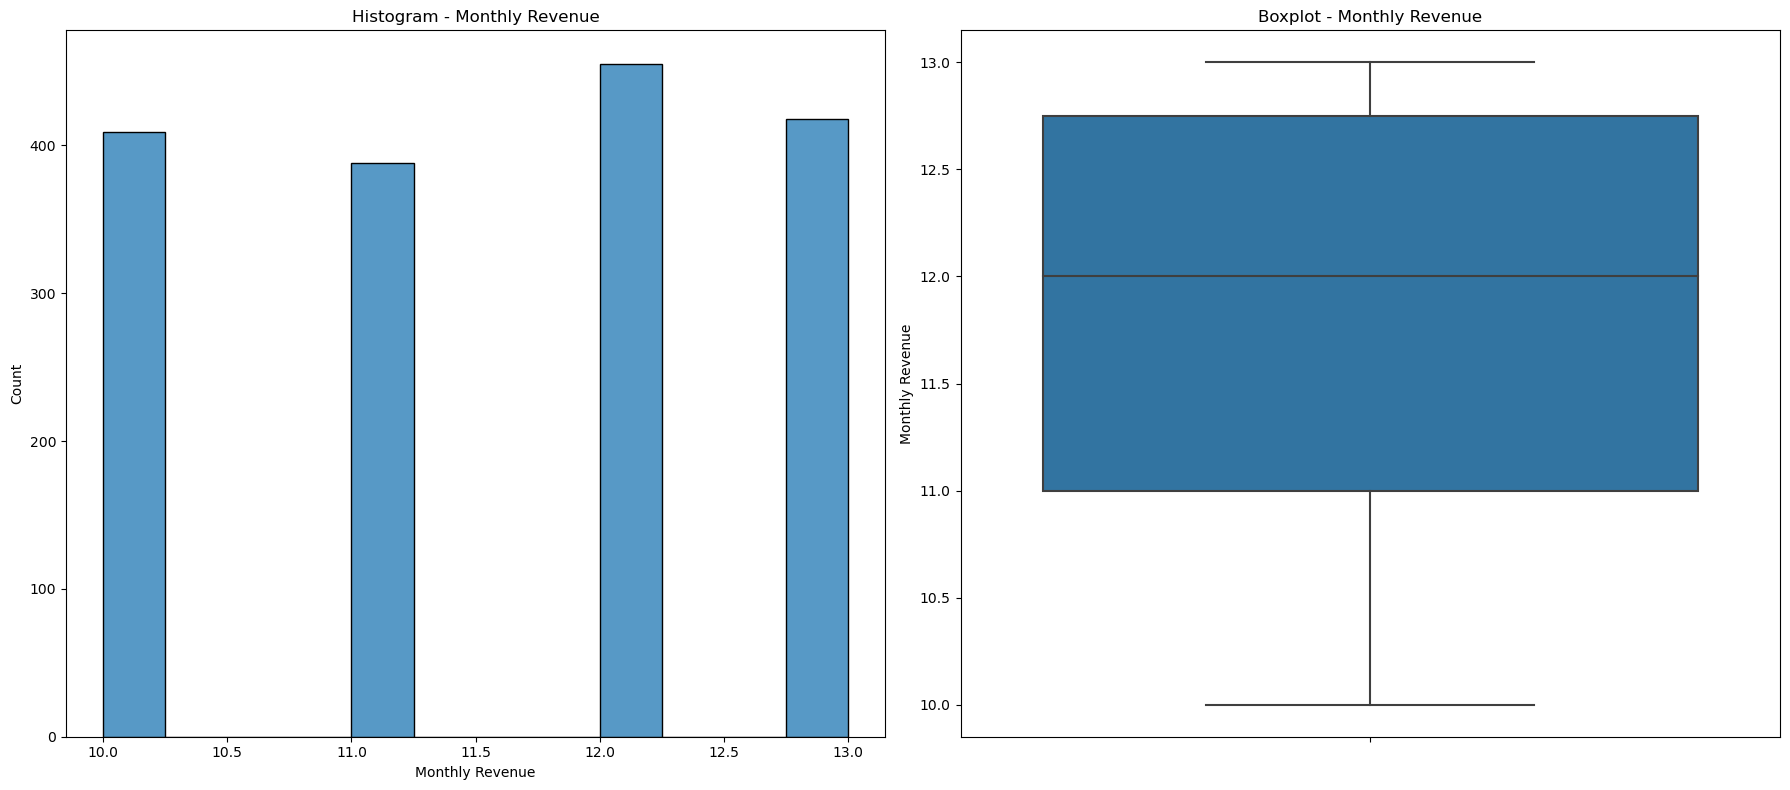

In [37]:
var='Monthly Revenue'

plt.figure(figsize = (18,8))
#count plot
plt.subplot(1,2,1)
#Filtering data for a value close to 75 th percentile only for better visualization
sns.histplot(x=var,data=df[df['Monthly Revenue']<14])
plt.title(f'Histogram - {var}')

#piechart
plt.subplot(1,2,2)
sns.boxplot(y=var,data=df[df['Monthly Revenue']<14])
plt.title(f'Boxplot - {var}')

#Adjust layout
plt.tight_layout()

#show the plots
plt.show()

In [38]:
##Bivariate Analysis

In [39]:
df.columns

Index(['Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device'],
      dtype='object')

In [40]:
ct_conversion_Subscription_type=pd.crosstab(df['Subscription Type'],df['Monthly Revenue'],normalize='index')
ct_conversion_Subscription_type

Monthly Revenue,10,11,12,13,14,15
Subscription Type,,,,,,
Basic,0.160160,0.169169,0.180180,0.168168,0.164164,0.158158
Premium,0.174625,0.135061,0.156889,0.170532,0.184175,0.178718
Standard,0.157552,0.156250,0.208333,0.162760,0.171875,0.143229


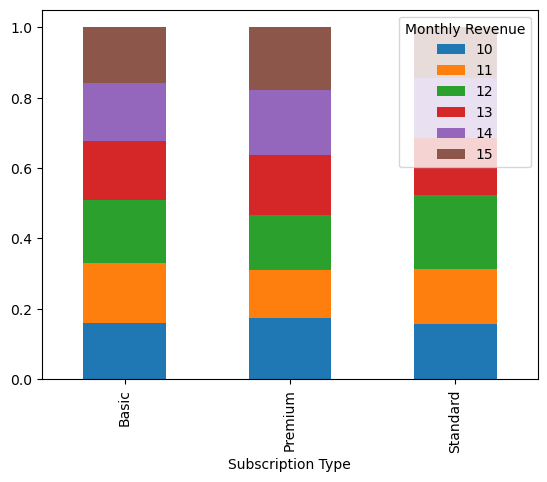

In [42]:
ct_conversion_Subscription_type.plot.bar(stacked=True);

Monthly Revenue        10        11        12        13        14        15
Age                                                                        
51               0.193548  0.204301  0.150538  0.204301  0.129032  0.118280
50               0.166667  0.166667  0.095238  0.226190  0.250000  0.095238
49               0.144330  0.185567  0.144330  0.195876  0.195876  0.134021
48               0.227723  0.158416  0.217822  0.118812  0.128713  0.148515
47               0.162162  0.108108  0.153153  0.189189  0.252252  0.135135
46               0.171717  0.141414  0.222222  0.171717  0.151515  0.141414
45               0.168539  0.112360  0.168539  0.191011  0.157303  0.202247
44               0.174419  0.162791  0.104651  0.162791  0.197674  0.197674
43               0.127660  0.127660  0.202128  0.223404  0.138298  0.180851
42               0.166667  0.156863  0.176471  0.264706  0.117647  0.117647
41               0.105263  0.157895  0.166667  0.228070  0.192982  0.149123
40          

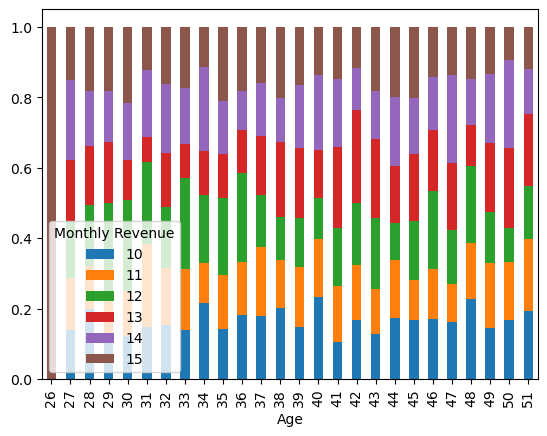

In [49]:
ct_conversion_Age=pd.crosstab(df['Age'],df['Monthly Revenue'],normalize='index')
print(ct_conversion_Age.sort_values(by='Age', ascending=False))
ct_conversion_Age.plot.bar(stacked=True);

Monthly Revenue        10        11        12        13        14        15
Country                                                                    
United States    0.166297  0.135255  0.190687  0.170732  0.155211  0.181818
United Kingdom   0.131148  0.147541  0.213115  0.147541  0.153005  0.207650
Spain            0.146341  0.177384  0.166297  0.155211  0.195122  0.159645
Mexico           0.213115  0.120219  0.229508  0.207650  0.125683  0.103825
Italy            0.163934  0.114754  0.191257  0.153005  0.180328  0.196721
Germany          0.185792  0.207650  0.120219  0.191257  0.147541  0.147541
France           0.136612  0.169399  0.169399  0.158470  0.207650  0.158470
Canada           0.157729  0.170347  0.182965  0.160883  0.198738  0.129338
Brazil           0.169399  0.163934  0.158470  0.196721  0.142077  0.169399
Australia        0.191257  0.131148  0.207650  0.147541  0.191257  0.131148


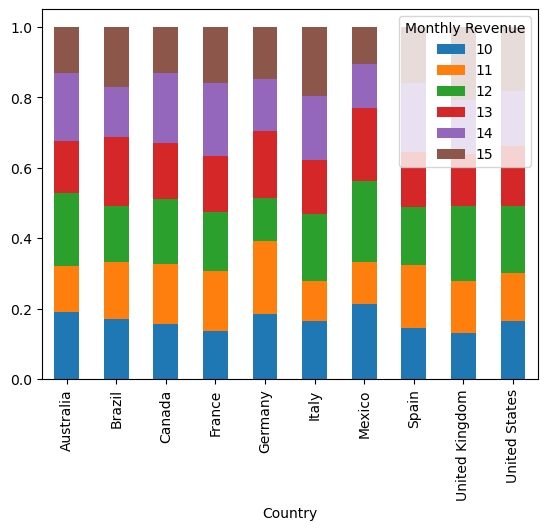

In [50]:
ct_conversion_Country=pd.crosstab(df['Country'],df['Monthly Revenue'],normalize='index')
print(ct_conversion_Country.sort_values(by='Country', ascending=False))
ct_conversion_Country.plot.bar(stacked=True);

Monthly Revenue        10        11        12        13        14        15
Gender                                                                     
Female           0.168656  0.143994  0.186953  0.161496  0.178202  0.160700
Male             0.158488  0.166533  0.176991  0.172969  0.166533  0.158488


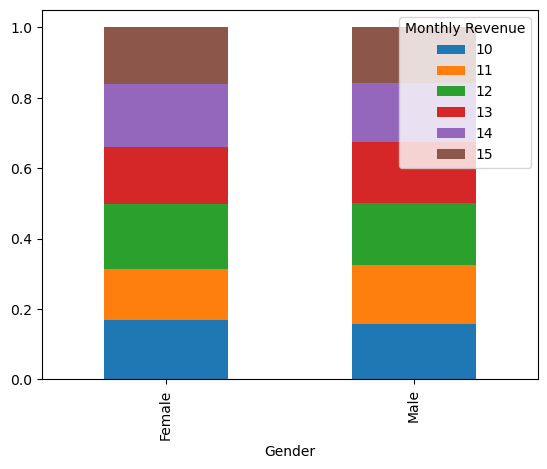

In [52]:
ct_conversion_Gender=pd.crosstab(df['Gender'],df['Monthly Revenue'],normalize='index')
print(ct_conversion_Gender)
ct_conversion_Gender.plot.bar(stacked=True);

<Axes: xlabel='Monthly Revenue', ylabel='Subscription Type'>

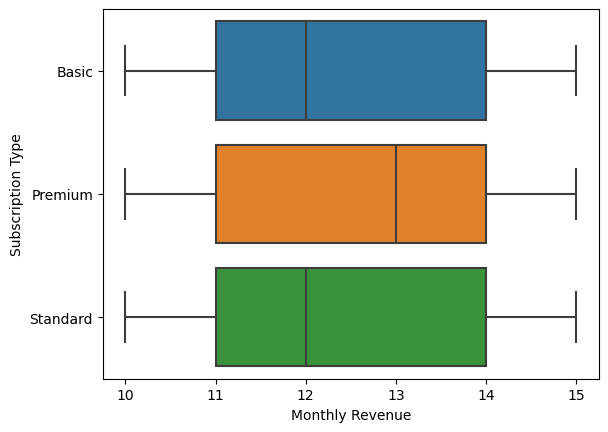

In [54]:
sns.boxplot(x='Monthly Revenue',y='Subscription Type', data = df)

<Axes: xlabel='Monthly Revenue', ylabel='Age'>

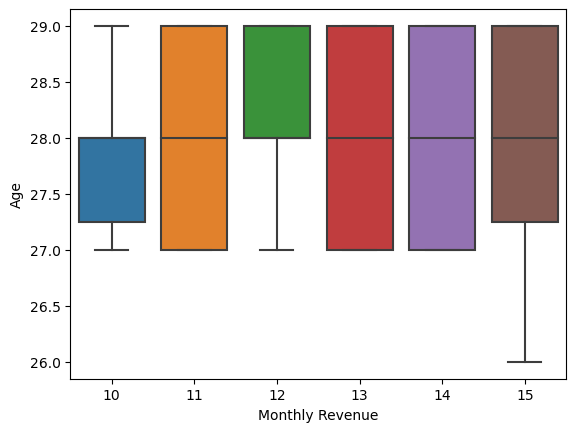

In [56]:
sns.boxplot(x='Monthly Revenue',y='Age', data = df[df['Age']<30])

In [80]:
from scipy.stats import chi2_contingency
alpha=0.05
for var in df_category.columns:
    if var!= 'Monthly Revenue':
        #Create a contigency table (cross-tabulation)
        contigency_table=pd.crosstab(df_category[var],df['Monthly Revenue'])
        
        #perform chi-squared test
        chi2, p, _, _=chi2_contingency(contigency_table)
        
        #Display the results
        print(f'\nChi-squared test for {var} vs. Monthly Revenue:')
        print(f'Chi-squared value:{chi2}')
        print(f'p-value:{p}')
        
        #check for significance
        if p < alpha:
            print(f'The difference in profit across {var} is statistically significant.')
        else:
            print(f'There is no significant difference in the profit accross {var}.')


Chi-squared test for Subscription Type vs. Monthly Revenue:
Chi-squared value:13.559129439495736
p-value:0.1940671111035544
There is no significant difference in the profit accross Subscription Type.

Chi-squared test for Country vs. Monthly Revenue:
Chi-squared value:53.93129877178699
p-value:0.16984993258501707
There is no significant difference in the profit accross Country.

Chi-squared test for Gender vs. Monthly Revenue:
Chi-squared value:3.7863024155260416
p-value:0.5805748683412534
There is no significant difference in the profit accross Gender.

Chi-squared test for Device vs. Monthly Revenue:
Chi-squared value:20.18709162614477
p-value:0.16487250811196644
There is no significant difference in the profit accross Device.


In [89]:
from scipy.stats import shapiro, levene ,  mannwhitneyu

# Check the number of data points in each group
true_group_size = len(df[df['Monthly Revenue'] == True]['Age'])
false_group_size = len(df[df['Monthly Revenue'] == False]['Age'])

# Normality Assumption
if true_group_size >= 3:
    shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['Monthly Revenue'] == True]['Age'])
    print(f'Shapiro-Wilk test for normality (True group): p-value = {shapiro_p_value_true}')
else:
    print(f"True group has fewer than 3 data points (size: {true_group_size}), skipping Shapiro-Wilk test.")

if false_group_size >= 3:
    shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['Monthly Revenue'] == False]['Age'])
    print(f'Shapiro-Wilk test for normality (False group): p-value = {shapiro_p_value_false}')
else:
    print(f"False group has fewer than 3 data points (size: {false_group_size}), skipping Shapiro-Wilk test.")

# Equality of variances assumption
if true_group_size >= 3 and false_group_size >= 3:
    levene_stat, levene_p_value = levene(df[df['Monthly Revenue'] == True]['Age'], df[df['Monthly Revenue'] == False]['Age'])
    print(f"Levene's test for equality of variances: p-value = {levene_p_value}")
else:
    print("Levene's test skipped due to insufficient data points in one or both groups.")

True group has fewer than 3 data points (size: 0), skipping Shapiro-Wilk test.
False group has fewer than 3 data points (size: 0), skipping Shapiro-Wilk test.
Levene's test skipped due to insufficient data points in one or both groups.
